# Let's learn about birds


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

birds = pd.read_csv("../../data/birds.csv")
birds.head()

,Name,ScientificName,Category,Order,Family,Genus,ConservationStatus,MinLength,MaxLength,MinBodyMass,MaxBodyMass,MinWingspan,MaxWingspan
0,Black-bellied whistling-duck,Dendrocygna autumnalis,Ducks/Geese/Waterfowl,Anseriformes,Anatidae,Dendrocygna,LC,47.0,56.0,652.0,1020.0,76.0,94.0
1,Fulvous whistling-duck,Dendrocygna bicolor,Ducks/Geese/Waterfowl,Anseriformes,Anatidae,Dendrocygna,LC,45.0,53.0,712.0,1050.0,85.0,93.0
2,Snow goose,Anser caerulescens,Ducks/Geese/Waterfowl,Anseriformes,Anatidae,Anser,LC,64.0,79.0,2050.0,4050.0,135.0,165.0
3,Ross's goose,Anser rossii,Ducks/Geese/Waterfowl,Anseriformes,Anatidae,Anser,LC,57.3,64.0,1066.0,1567.0,113.0,116.0
4,Greater white-fronted goose,Anser albifrons,Ducks/Geese/Waterfowl,Anseriformes,Anatidae,Anser,LC,64.0,81.0,1930.0,3310.0,130.0,165.0


Plot a view of the maximum wingspan, using a basic line plot.

<Axes: >

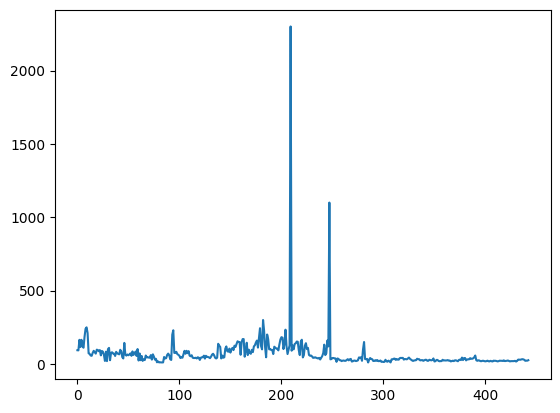

In [13]:
birds["MaxWingspan"].plot()

There seems to be at least one **outlier**; a wingspan of 2300cm is 23 meters!<br/>
Let's investigate.

We will continue the visualization process by adding labels to the x-axis to show what kind of birds are in question.

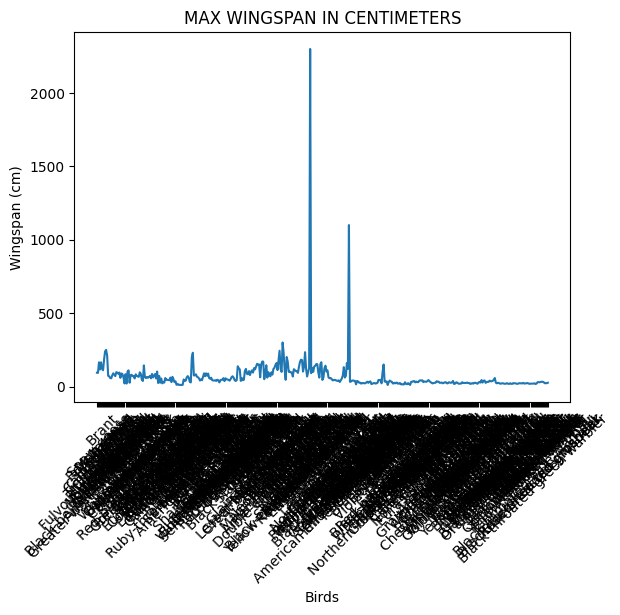

In [25]:
fig, ax = plt.subplots()

ax.set_title("MAX WINGSPAN IN CENTIMETERS")
ax.set_ylabel("Wingspan (cm)")
ax.set_xlabel("Birds")
ax.tick_params(axis="x", rotation=45)

ax.plot(birds["Name"], birds["MaxWingspan"])

plt.show()

Again there are too many labels to read!<br/>
Let's try labeling only the outliers, and keep the labels within the chart.<br/>
We'll use a scatter chart to make more room for the labels which we shall print only if the max wingspan is greater than, say 500 cm.

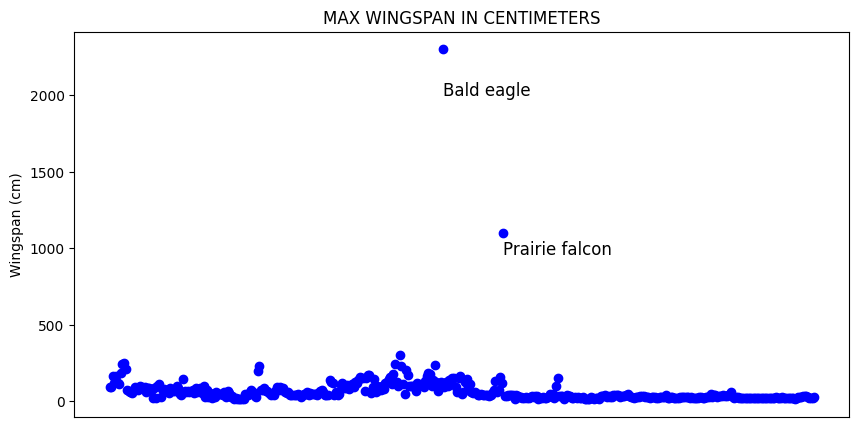

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.set_title("MAX WINGSPAN IN CENTIMETERS")
ax.set_ylabel("Wingspan (cm)")
ax.tick_params(axis="both", which="both", labelbottom=False, bottom=False)

for i in range(len(birds)):
    x = birds["Name"][i]
    y = birds["MaxWingspan"][i]
    ax.plot(x, y, "bo")

    if birds["MaxWingspan"][i] > 500:
        ax.text(x, y * (1 - 0.13), birds["Name"][i], fontsize=12)

plt.show()

# Filter your Data

It looks as though that both Bald eagle and Prairie falcon, have been mislabeled with an extra 0 added to their maximum wingspan.

Let's create a new DataFrame *without those two outliers*.

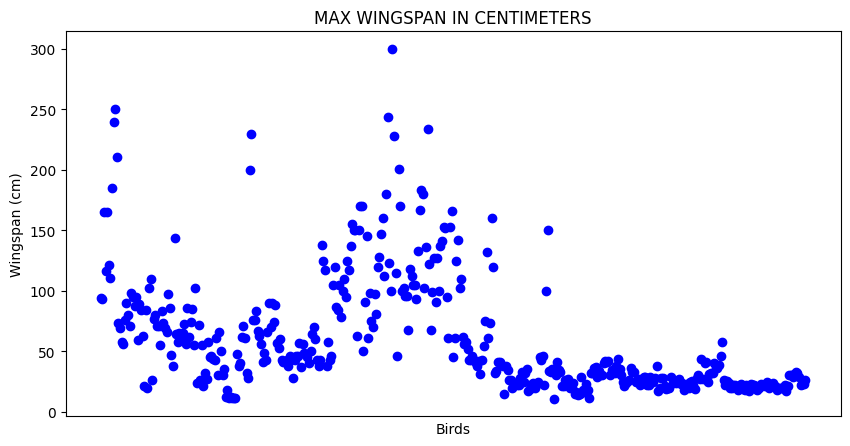

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.set_title("MAX WINGSPAN IN CENTIMETERS")
ax.set_ylabel("Wingspan (cm)")
ax.set_xlabel("Birds")
ax.tick_params(axis="both", which="both", labelbottom=False, bottom=False)

for i in range(len(birds)):
    x = birds["Name"][i]
    y = birds["MaxWingspan"][i]

    if x not in ["Bald eagle", "Prairie falcon"]:
        ax.plot(x, y, "bo")

plt.show()

# Explore Bar Charts

Next, we plot the categories of birds to see which is the most common by number. To show such groupings of data, we usually use a `bar chart`.

We'll leave the two outlier birds intact, as this plot doesn't depend on wingspan values.

<Axes: title={'center': 'Birds of Minnesota'}, xlabel='Category'>

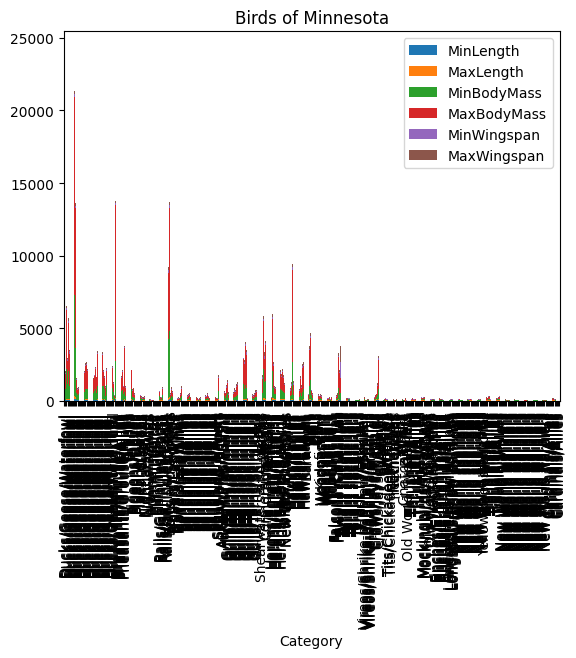

In [43]:
birds.plot(x="Category", kind="bar", stacked=True, title="Birds of Minnesota")

Filter the data to include only bird's category. Since there are many categories, we display the chart vetically and adjust the vertical height accordingly.

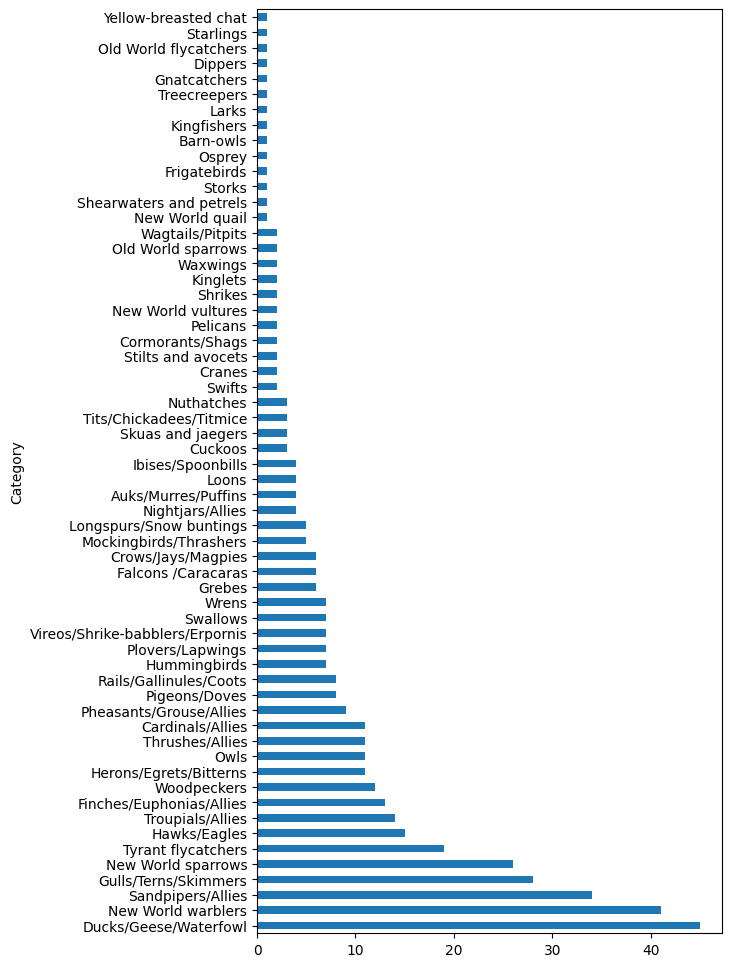

In [ ]:
category_count = birds["Category"].value_counts()
plt.rcParams["figure.figsize"] = (6, 12)
category_count.plot.barh()

plt.show()

Just by looking at the bar chart, we can see that the largest group of birds is the "Ducks/Geese/Waterfowl" category. This is explained if we take into account that Minesotta has thousands of lakes!

# Comparing Data

Let's compare the MaxLength of a bird, based on its category

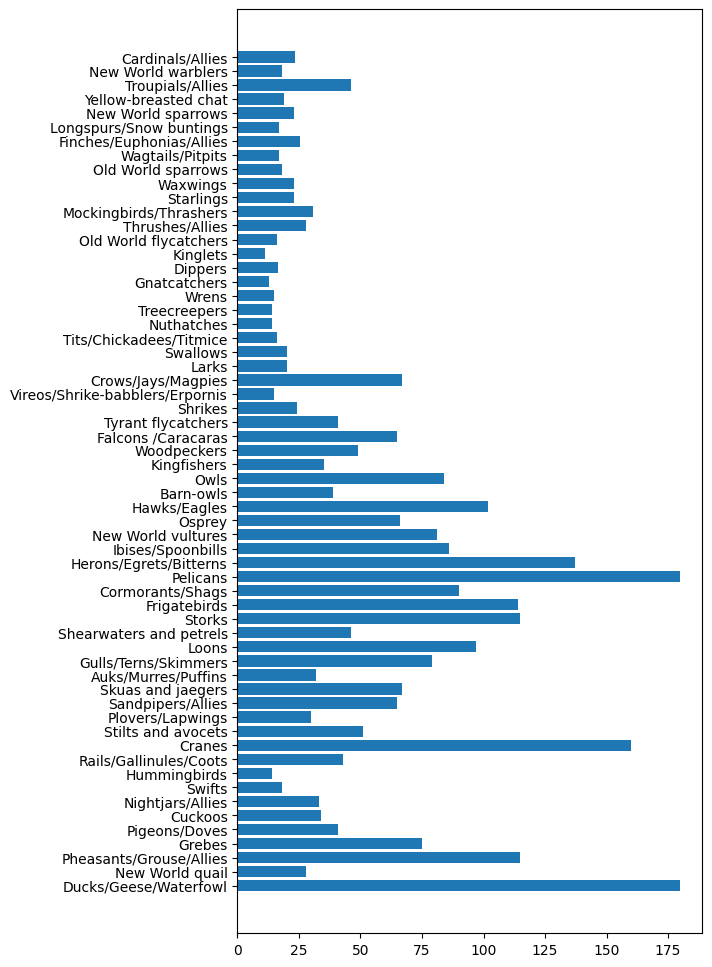

In [ ]:
plt.barh(y=birds["Category"], width=birds["MaxLength"])
plt.rcParams["figure.figsize"] = (6, 12)

plt.show()

The graph confirms expectations: Hummingbirds have the least MaxLength compared to Ducks or Cranes or Pelicans.
Now, let's superimpose Minimun and Maximum Length, based on Category:

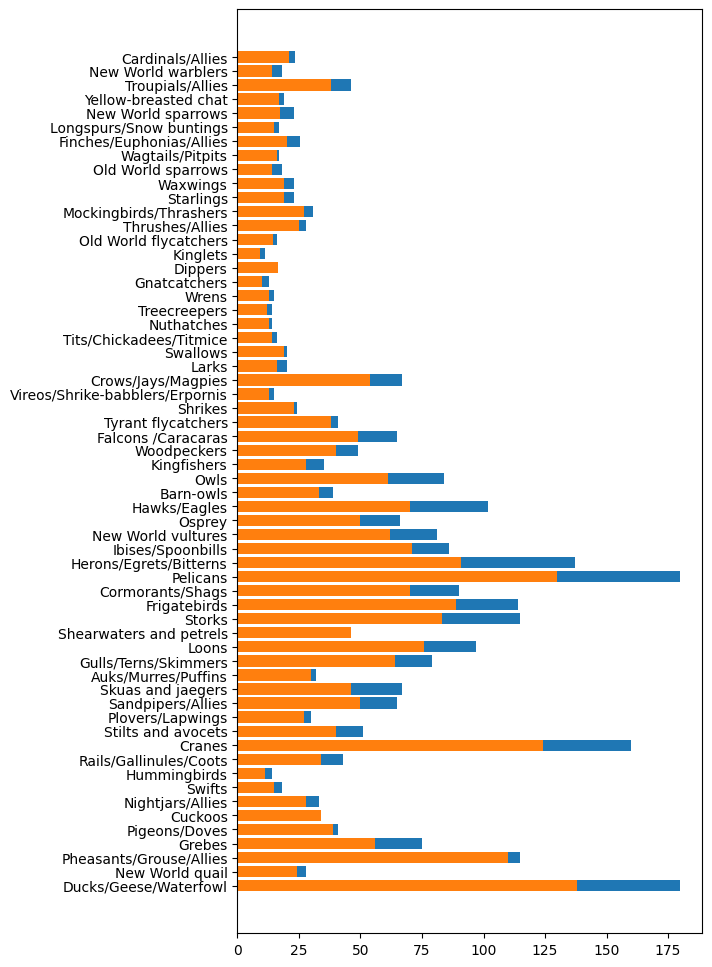

In [52]:
minLength = birds["MinLength"]
maxLength = birds["MaxLength"]
category = birds["Category"]

plt.barh(category, maxLength)
plt.barh(category, minLength)

plt.show()

From the graph we can say that the bigger the bird, the larger its length range.